# Notebook 6 — K-Nearest Neighbors (KNN)

KNN is one of the simplest machine learning algorithms — it makes
predictions by looking at the points **closest** to it and going with
whatever they mostly are (or their average value).

We'll use the same retail dataset from the earlier notebooks.

### Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score

### Load the Data

Same cleanup as before: load the file, keep valid rows, and build a
`HighValue` label (1 = above median order price, 0 = below).

In [3]:
data = pd.read_csv("data.csv", encoding="latin1")
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
data = data.sample(200, random_state=1).reset_index(drop=True)
median_price = data["TotalPrice"].median()
data["HighValue"] = (data["TotalPrice"] > median_price).astype(int)
data[["Quantity", "UnitPrice", "TotalPrice", "HighValue"]].head()

,Quantity,UnitPrice,TotalPrice,HighValue
0,6,7.95,47.70,1
1,2,1.25,2.50,0
2,3,1.25,3.75,0
3,1,8.47,8.47,0
4,2,3.75,7.50,0


## 1. What is KNN?

**K-Nearest Neighbors (KNN)** predicts something about a new point by
looking at the **K closest points** to it in the existing data, and
letting them "vote" on the answer.

No fancy formula gets learned — KNN just remembers all the data, and does
the comparison at prediction time. That's why it's called a **lazy
learner**.

## 2. Distance

To find the "nearest" neighbors, KNN needs a way to measure how **close**
two points are — that's **distance**. The smaller the distance, the more
similar two points are considered.

## 3. Euclidean Distance

The most common distance measure is **Euclidean Distance** — basically the
straight-line distance between two points, like measuring with a ruler.

$$ distance = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2} $$

In [4]:
point_a = np.array([2, 3])
point_b = np.array([5, 7])
distance = np.sqrt(np.sum((point_a - point_b) ** 2))
print("Euclidean distance:", distance)

Euclidean distance: 5.0


## 4. Neighbors

The **neighbors** of a point are simply the other data points closest to
it, based on that distance measurement. KNN looks at the K nearest
neighbors and uses them to make its prediction.

## 5. Feature Scaling

KNN compares raw distances, so features with bigger numbers (like
`UnitPrice` in the hundreds) can completely dominate features with smaller
numbers (like `Quantity`), even if both matter equally.

**Feature Scaling** fixes this by putting all features on the same scale
before measuring distance.

In [6]:
features = data[["Quantity", "UnitPrice"]]
target = data["HighValue"]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
print("Before scaling (first row):", features.iloc[0].values)
print("After scaling (first row): ", features_scaled[0])

Before scaling (first row): [6.   7.95]
After scaling (first row):  [-0.09649254  1.52951314]


## 6. Classification with KNN

For **classification**, KNN looks at the K nearest neighbors and predicts
whichever class is the **majority** among them.

Let's predict `HighValue` (1 or 0) using `Quantity` and `UnitPrice`.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, target, test_size=0.2, random_state=1
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy with K=5:", round(accuracy, 2))

Accuracy with K=5: 0.82


## 7. Choosing K

**K** is the number of neighbors the model looks at. Picking the right K
matters a lot:

- **Small K** (like 1) → very sensitive to noise, can overfit
- **Large K** → smoother predictions, but can miss real patterns

The best way to choose K is to just try several values and see which one
performs best.

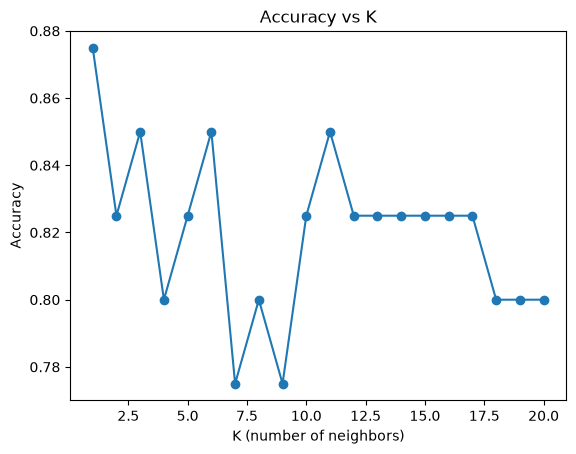

Best K: 1 with accuracy: 0.88


In [8]:
k_values = range(1, 21)
accuracies = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, preds))
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()
best_k = k_values[np.argmax(accuracies)]
print("Best K:", best_k, "with accuracy:", round(max(accuracies), 2))

## 8. Regression with KNN

KNN isn't just for categories — it can also predict **numbers**. For
**regression**, instead of voting on a class, it averages the values of
the K nearest neighbors.

Let's predict `TotalPrice` from `Quantity` using KNN Regression.

In [9]:
x_reg = data[["Quantity"]]
y_reg = data["TotalPrice"]
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(x_reg, y_reg)
new_order = [[10]]
predicted_price = knn_reg.predict(new_order)
print("Predicted Total Price for Quantity=10:", round(predicted_price[0], 2))

Predicted Total Price for Quantity=10: 21.3


C:\Users\hemak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


## 9. Advantages

- Simple to understand and easy to implement
- No training step — it just stores the data
- Works for both classification and regression
- Naturally handles multiple classes

## 10. Limitations

- Slow on large datasets (it compares against every point each time)
- Needs feature scaling to work well
- Sensitive to irrelevant features and noisy data
- Choosing the wrong K can hurt accuracy a lot